# **Matplotlib Dashboard & Visualization**

**Tables:** KPI Summary, Monthly Trend, Category Performance, State Performance, Segment Summary, CLV Table
**Charts:**

* Line → Monthly Revenue
* Bar → Category Revenue & Profit
* Map → State Revenue
* Pie → Segment Distribution
* Pareto Curve → Revenue concentration
* Heatmap → Cohort Retention

**Business Impact:**

* Fast, **data-driven decisions**
* Margin control & retention improvement
* Risk detection & operational optimization
* **Investor-ready presentation**
---

In [22]:
import os

# Check what CSV files exist in your project
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

./state_performance_summary.csv
./state_performance_summary-Copy1.csv
./df_finale.csv
./category_revenue.csv
./monthly_revenue.csv
./category_performance_summary.csv
./df.csv
./segment_summary.csv
./monthly_performance_summary.csv
./.ipynb_checkpoints/state_performance_summary-checkpoint.csv
./.ipynb_checkpoints/category_performance_summary-checkpoint.csv


In [33]:
import pandas as pd

df_finale                         = pd.read_csv('./df.csv')
df                            = pd.read_csv('./df_finale.csv')
monthly_performance_summary  = pd.read_csv('./monthly_performance_summary.csv')
category_performance_summary = pd.read_csv('./category_performance_summary.csv')
state_performance_summary    = pd.read_csv('./state_performance_summary.csv')
segment_summary              = pd.read_csv('./segment_summary.csv')

print("✅ All loaded!")

✅ All loaded!


In [34]:
datasets = {
    'df'                          : df,
    'df_finale'                   : df_finale,
    'monthly_performance_summary' : monthly_performance_summary,
    'category_performance_summary': category_performance_summary,
    'state_performance_summary'   : state_performance_summary,
    'segment_summary'             : segment_summary,
}

for name, data in datasets.items():
    print(f"\n✅ {name}: {data.shape}")
    print(data.columns.tolist())


✅ df: (115011, 43)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'revenue', 'cost', 'profit', 'year', 'month', 'day', 'weekday', 'purchase_month', 'Cohort_Month', 'Cohort_Index']

✅ df_finale: (115030, 33)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_d

In [35]:
for name, data in datasets.items():
    print(f"\n📋 {name}:")
    print(data.columns.tolist())
    print(data.head(2))


📋 df:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'revenue', 'cost', 'profit', 'year', 'month', 'day', 'weekday', 'purchase_month', 'Cohort_Month', 'Cohort_Index']
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6

In [50]:
df['purchase_month'] = pd.to_datetime(df['purchase_month'])
monthly_clean['purchase_month'] = pd.to_datetime(monthly_clean['purchase_month'])

print(df['purchase_month'].dtype)
# Should show: datetime64[ns]

datetime64[ns]


In [56]:
translation = pd.read_csv('../olistdataser/product_category_name_translation.csv')
print(translation.head(3))
print(translation.columns.tolist())

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
['product_category_name', 'product_category_name_english']


In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# ✅ A. PERFORMANCE ANALYSIS .

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115011 entries, 0 to 115010
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       115011 non-null  object        
 1   customer_id                    115011 non-null  object        
 2   order_status                   115011 non-null  object        
 3   order_purchase_timestamp       115011 non-null  datetime64[ns]
 4   order_approved_at              115011 non-null  object        
 5   order_delivered_carrier_date   115011 non-null  object        
 6   order_delivered_customer_date  115011 non-null  object        
 7   order_estimated_delivery_date  115011 non-null  object        
 8   order_item_id                  115011 non-null  int64         
 9   product_id                     115011 non-null  object        
 10  seller_id                      115011 non-null  object        
 11  

### 1️⃣ Monthly Revenue Trend (Mandatory)

* Line chart
* Revenue
* Add Profit line
* Add MoM Growth %

✔ Detect growth
✔ Detect seasonality
✔ Detect revenue drops

---

In [41]:


# Convert purchase_month to datetime so x axis sorts properly
monthly_performance_summary['purchase_month'] = pd.to_datetime(
    monthly_performance_summary['purchase_month']
)

# Remove rows where revenue is 0 (empty months like 2016-11)
monthly_clean = monthly_performance_summary[
    monthly_performance_summary['total_revenue'] > 0
].copy()

print(monthly_clean[['purchase_month', 'total_revenue', 'total_profit']].head())

  purchase_month  total_revenue  total_profit
0     2016-10-01       48133.30      14789.48
2     2016-12-01          19.62         10.90
3     2017-01-01      136634.49      40604.42
4     2017-02-01      283420.83      87946.99
5     2017-03-01      440064.65     135020.18


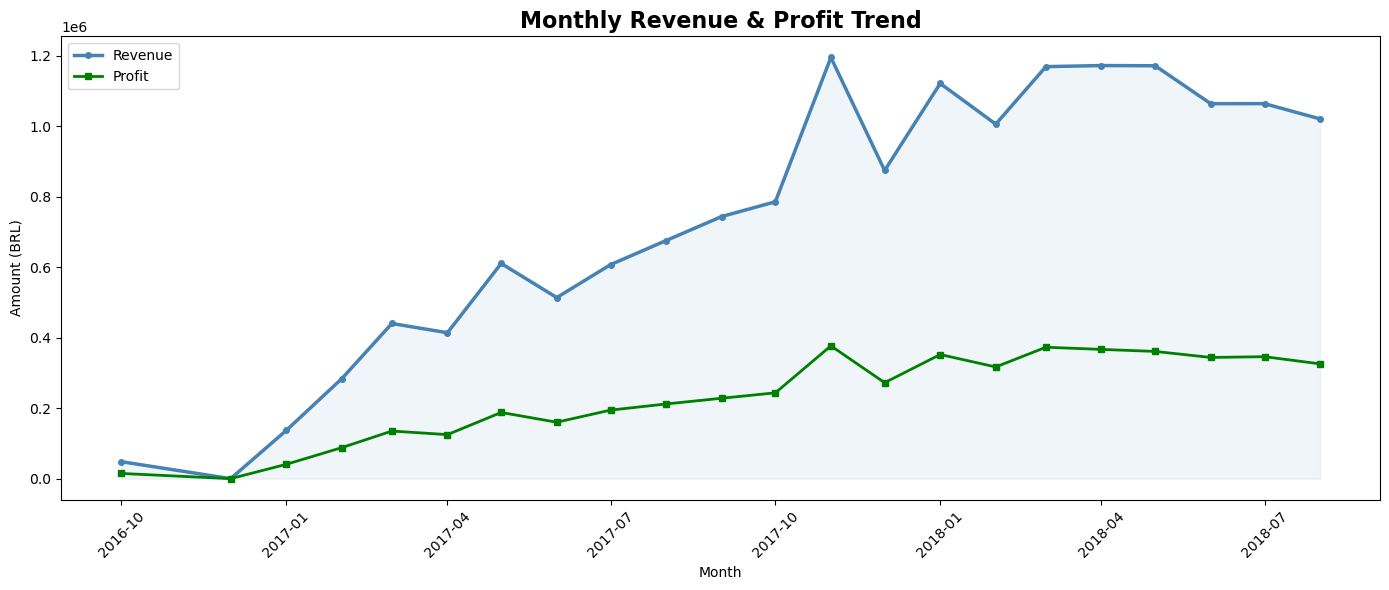

In [42]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Revenue Line ---
ax1.plot(monthly_clean['purchase_month'],
         monthly_clean['total_revenue'],
         color='steelblue', linewidth=2.5,
         marker='o', markersize=4, label='Revenue')

# --- Profit Line ---
ax1.plot(monthly_clean['purchase_month'],
         monthly_clean['total_profit'],
         color='green', linewidth=2,
         marker='s', markersize=4, label='Profit')

# --- Fill under Revenue ---
ax1.fill_between(monthly_clean['purchase_month'],
                 monthly_clean['total_revenue'],
                 alpha=0.08, color='steelblue')

# --- Labels ---
ax1.set_title('Monthly Revenue & Profit Trend', fontsize=16, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Amount (BRL)')
ax1.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2️⃣ Monthly Orders Trend

* Line chart
* Total orders per month

✔ Demand growth
✔ Customer activity

---

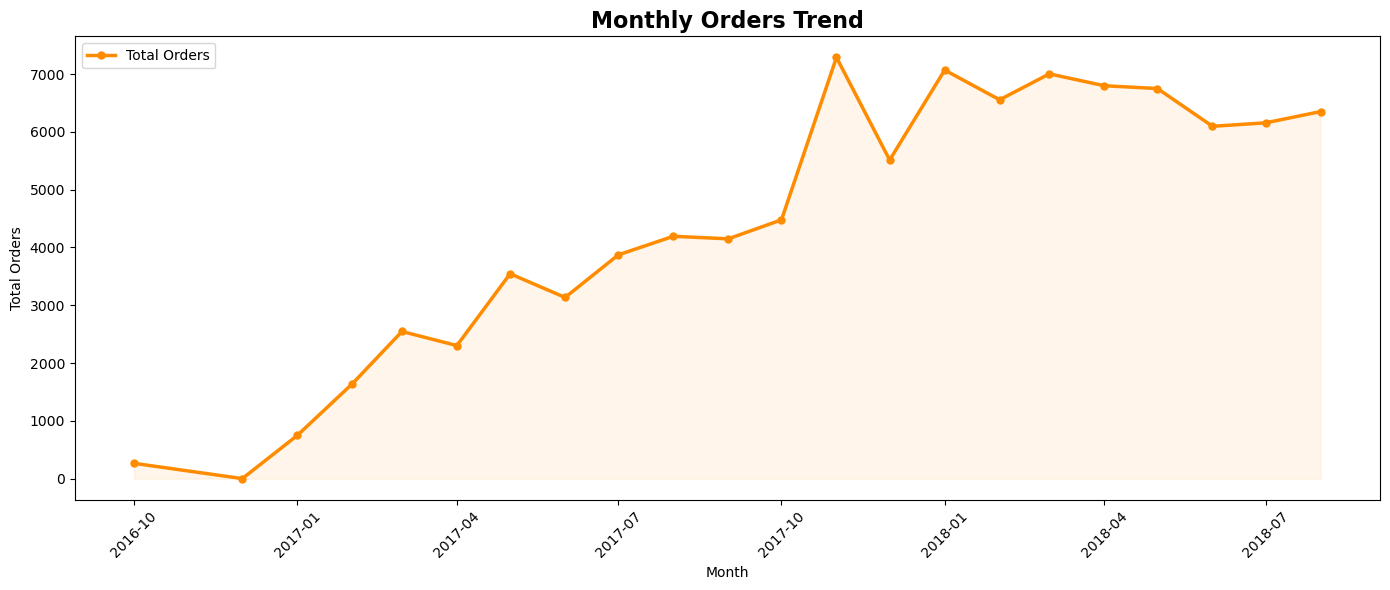

In [43]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_clean['purchase_month'],
        monthly_clean['total_orders'],
        color='darkorange', linewidth=2.5,
        marker='o', markersize=5,
        label='Total Orders')

ax.fill_between(monthly_clean['purchase_month'],
                monthly_clean['total_orders'],
                alpha=0.08, color='darkorange')

ax.set_title('Monthly Orders Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Orders')
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3️⃣ Monthly AOV Trend

* Revenue / Orders

✔ Are customers spending more?.                            
✔ Pricing improvement?.                                 

--------

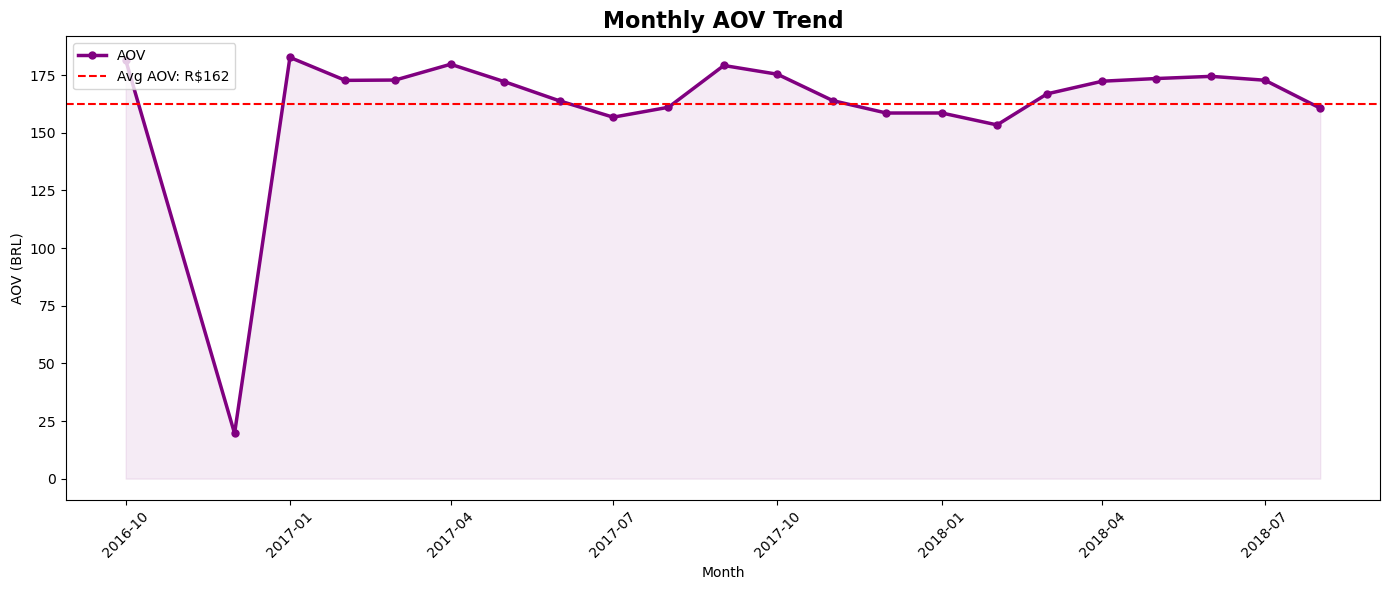

In [44]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_clean['purchase_month'],
        monthly_clean['AOV'],
        color='purple', linewidth=2.5,
        marker='o', markersize=5,
        label='AOV')

ax.fill_between(monthly_clean['purchase_month'],
                monthly_clean['AOV'],
                alpha=0.08, color='purple')

# Add horizontal average line
avg_aov = monthly_clean['AOV'].mean()
ax.axhline(y=avg_aov, color='red', linewidth=1.5,
           linestyle='--', label=f'Avg AOV: R${avg_aov:.0f}')

ax.set_title('Monthly AOV Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('AOV (BRL)')
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4️⃣ Monthly Profit Trend

✔ Margin stability.                                     
✔ Cost pressure months.                             

------

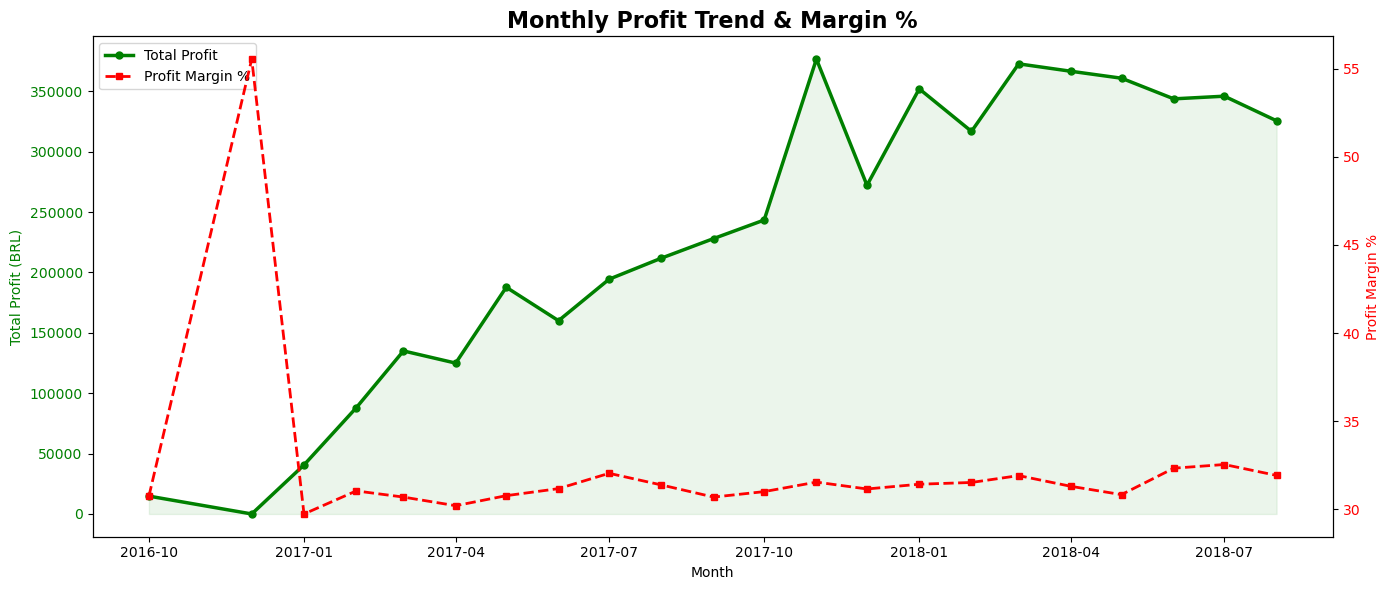

In [45]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Left Y axis — Profit ---
ax1.plot(monthly_clean['purchase_month'],
         monthly_clean['total_profit'],
         color='green', linewidth=2.5,
         marker='o', markersize=5,
         label='Total Profit')

ax1.fill_between(monthly_clean['purchase_month'],
                 monthly_clean['total_profit'],
                 alpha=0.08, color='green')

ax1.set_ylabel('Total Profit (BRL)', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# --- Right Y axis — Margin % ---
ax2 = ax1.twinx()

ax2.plot(monthly_clean['purchase_month'],
         monthly_clean['profit_margin_%'],
         color='red', linewidth=2,
         marker='s', markersize=4,
         linestyle='--', label='Profit Margin %')

ax2.set_ylabel('Profit Margin %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- Labels ---
ax1.set_title('Monthly Profit Trend & Margin %',
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Month')

# --- Combined Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### 5️⃣ Revenue vs Profit Margin Trend

Dual axis line chart

✔ If revenue ↑ but margin ↓ → cost issue.                        

---------

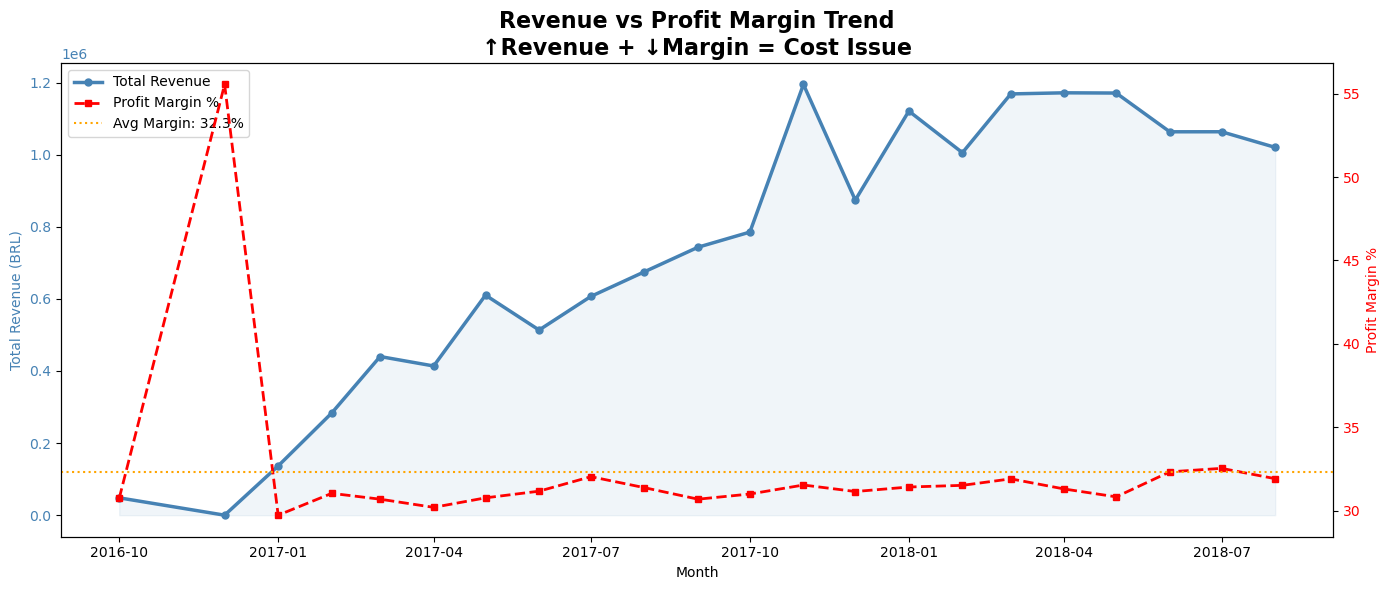

In [46]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Left Y Axis — Revenue ---
ax1.plot(monthly_clean['purchase_month'],
         monthly_clean['total_revenue'],
         color='steelblue', linewidth=2.5,
         marker='o', markersize=5,
         label='Total Revenue')

ax1.fill_between(monthly_clean['purchase_month'],
                 monthly_clean['total_revenue'],
                 alpha=0.08, color='steelblue')

ax1.set_ylabel('Total Revenue (BRL)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# --- Right Y Axis — Margin % ---
ax2 = ax1.twinx()

ax2.plot(monthly_clean['purchase_month'],
         monthly_clean['profit_margin_%'],
         color='red', linewidth=2,
         marker='s', markersize=4,
         linestyle='--',
         label='Profit Margin %')

# --- Danger Zone --- 
avg_margin = monthly_clean['profit_margin_%'].mean()
ax2.axhline(y=avg_margin, color='orange',
            linewidth=1.5, linestyle=':',
            label=f'Avg Margin: {avg_margin:.1f}%')

ax2.set_ylabel('Profit Margin %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- Labels ---
ax1.set_title('Revenue vs Profit Margin Trend\n↑Revenue + ↓Margin = Cost Issue',
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Month')

# --- Combined Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ✅ B. PRODUCT PERFORMANCE

### 6️⃣ Top 10 Categories by Revenue

Horizontal bar chart.                  

------------

In [60]:
monthly_clean['purchase_month'] = pd.to_datetime(monthly_clean['purchase_month'])
print("✅ datetime fixed:", monthly_clean['purchase_month'].dtype)

✅ datetime fixed: datetime64[ns]


In [61]:
# Sort ascending so top category appears at top of chart
df.sort_values('revenue', ascending=True).tail(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,revenue,cost,profit,year,month,day,weekday,purchase_month,Cohort_Month,Cohort_Index
22496,68101694e5c5dc7330c91e1bbc36214f,35a413c7ca3c69756cb75867d6311c0d,delivered,2018-03-29 10:31:29,2018-03-31 08:27:27,2018-04-04 23:26:45,2018-04-06 22:35:30,2018-04-17,1,6cdf8fc1d741c76586d8b6b15e9eef30,...,4175.26,3279.992,895.268,2018,3,29,Thursday,2018-03-01,2018-03-01,0
8788,80dfedb6d17bf23539beeef3c768f4d7,926b6a6fb8b6081e00b335edaf578d35,delivered,2017-04-18 20:37:26,2017-04-18 20:50:13,2017-04-25 14:08:56,2017-05-04 14:13:36,2017-05-16,1,4ca7b91a31637bd24fb8e559d5e015e4,...,4194.76,3199.200,995.560,2017,4,18,Tuesday,2017-04-01,2017-04-01,0
8789,80dfedb6d17bf23539beeef3c768f4d7,926b6a6fb8b6081e00b335edaf578d35,delivered,2017-04-18 20:37:26,2017-04-18 20:50:13,2017-04-25 14:08:56,2017-05-04 14:13:36,2017-05-16,1,4ca7b91a31637bd24fb8e559d5e015e4,...,4194.76,3199.200,995.560,2017,4,18,Tuesday,2017-04-01,2017-04-01,0
13444,426a9742b533fc6fed17d1fd6d143d7e,1afc82cd60e303ef09b4ef9837c9505c,delivered,2018-08-03 21:10:16,2018-08-06 14:24:28,2018-08-06 15:01:00,2018-08-08 22:51:57,2018-08-20,1,a1beef8f3992dbd4cd8726796aa69c53,...,4513.32,3519.896,993.424,2018,8,3,Friday,2018-08-01,2018-08-01,0
46696,8dbc85d1447242f3b127dda390d56e19,3d979689f636322c62418b6346b1c6d2,delivered,2018-06-22 12:23:19,2018-06-22 12:36:36,2018-06-22 13:00:00,2018-07-06 01:08:30,2018-07-17,1,259037a6a41845e455183f89c5035f18,...,4681.78,3672.000,1009.780,2018,6,22,Friday,2018-06-01,2018-06-01,0
46681,199af31afc78c699f0dbf71fb178d4d4,24bbf5fd2f2e1b359ee7de94defc4a15,delivered,2017-04-18 18:50:13,2017-04-19 15:50:15,2017-04-25 13:39:59,2017-05-07 10:42:39,2017-05-15,1,c3ed642d592594bb648ff4a04cee2747,...,4764.34,3752.000,1012.340,2017,4,18,Tuesday,2017-04-01,2017-04-01,0
61637,a96610ab360d42a2e5335a3998b4718a,df55c14d1476a9a3467f131269c2477f,delivered,2017-04-01 15:58:40,2017-04-03 13:25:18,2017-04-11 15:10:34,2017-04-17 11:04:45,2017-05-02,1,a6492cc69376c469ab6f61d8f44de961,...,4950.34,3839.200,1111.140,2017,4,1,Saturday,2017-04-01,2017-04-01,0
4029,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,delivered,2017-05-24 18:14:34,2017-05-26 02:45:17,2017-05-26 11:20:47,2017-06-05 17:09:48,2017-06-28,1,1bdf5e6731585cf01aa8169c7028d6ad,...,6726.66,5199.200,1527.460,2017,5,24,Wednesday,2017-05-01,2017-05-01,0
32809,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,delivered,2018-07-25 18:10:17,2018-07-27 04:05:13,2018-08-03 14:42:00,2018-08-15 14:57:50,2018-08-10,1,69c590f7ffc7bf8db97190b6cb6ed62e,...,6922.21,5383.200,1539.010,2018,7,25,Wednesday,2018-07-01,2018-07-01,0
25610,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,delivered,2017-02-12 20:37:36,2017-02-12 20:45:12,2017-02-16 09:23:13,2017-03-03 14:23:18,2017-03-09,1,489ae2aa008f021502940f251d4cce7f,...,6929.31,5388.000,1541.310,2017,2,12,Sunday,2017-02-01,2017-02-01,0


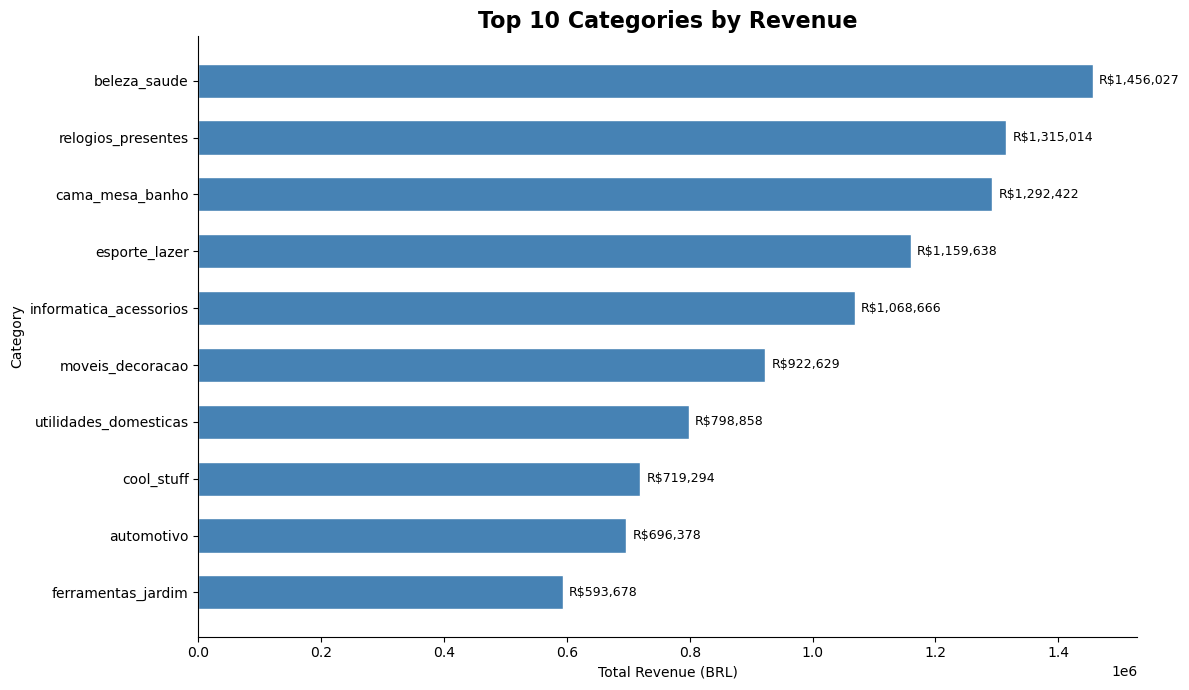

In [62]:
# --- Prepare Data ---
top10_revenue = (
    category_performance_summary
    .sort_values('total_revenue', ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(12, 7))

# --- Horizontal Bar ---
bars = ax.barh(top10_revenue['product_category_name'],
               top10_revenue['total_revenue'],
               color='steelblue',
               edgecolor='white',
               height=0.6)

# --- Value Labels ---
for bar in bars:
    width = bar.get_width()
    ax.text(width + 10000,
            bar.get_y() + bar.get_height() / 2,
            f'R${width:,.0f}',
            va='center', fontsize=9)

# --- Styling ---
ax.set_title('Top 10 Categories by Revenue',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Category')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 7️⃣ Top 10 Categories by Profit

Bar chart

------

In [63]:
df.sort_values('profit', ascending=True).tail(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,revenue,cost,profit,year,month,day,weekday,purchase_month,Cohort_Month,Cohort_Index
114122,43bdbd9dc0931d72befdf4765af6c442,3c7c62e8d38fb18a33a45db8021f2d69,delivered,2018-07-06 11:07:02,2018-07-10 08:35:21,2018-07-10 12:59:00,2018-07-24 20:16:54,2018-07-30,1,7e53e051875b2a0c9f22acd8a9a29a20,...,3406.47,2471.200,935.270,2018,7,6,Friday,2018-07-01,2018-07-01,0
13444,426a9742b533fc6fed17d1fd6d143d7e,1afc82cd60e303ef09b4ef9837c9505c,delivered,2018-08-03 21:10:16,2018-08-06 14:24:28,2018-08-06 15:01:00,2018-08-08 22:51:57,2018-08-20,1,a1beef8f3992dbd4cd8726796aa69c53,...,4513.32,3519.896,993.424,2018,8,3,Friday,2018-08-01,2018-08-01,0
8788,80dfedb6d17bf23539beeef3c768f4d7,926b6a6fb8b6081e00b335edaf578d35,delivered,2017-04-18 20:37:26,2017-04-18 20:50:13,2017-04-25 14:08:56,2017-05-04 14:13:36,2017-05-16,1,4ca7b91a31637bd24fb8e559d5e015e4,...,4194.76,3199.200,995.560,2017,4,18,Tuesday,2017-04-01,2017-04-01,0
8789,80dfedb6d17bf23539beeef3c768f4d7,926b6a6fb8b6081e00b335edaf578d35,delivered,2017-04-18 20:37:26,2017-04-18 20:50:13,2017-04-25 14:08:56,2017-05-04 14:13:36,2017-05-16,1,4ca7b91a31637bd24fb8e559d5e015e4,...,4194.76,3199.200,995.560,2017,4,18,Tuesday,2017-04-01,2017-04-01,0
46696,8dbc85d1447242f3b127dda390d56e19,3d979689f636322c62418b6346b1c6d2,delivered,2018-06-22 12:23:19,2018-06-22 12:36:36,2018-06-22 13:00:00,2018-07-06 01:08:30,2018-07-17,1,259037a6a41845e455183f89c5035f18,...,4681.78,3672.000,1009.780,2018,6,22,Friday,2018-06-01,2018-06-01,0
46681,199af31afc78c699f0dbf71fb178d4d4,24bbf5fd2f2e1b359ee7de94defc4a15,delivered,2017-04-18 18:50:13,2017-04-19 15:50:15,2017-04-25 13:39:59,2017-05-07 10:42:39,2017-05-15,1,c3ed642d592594bb648ff4a04cee2747,...,4764.34,3752.000,1012.340,2017,4,18,Tuesday,2017-04-01,2017-04-01,0
61637,a96610ab360d42a2e5335a3998b4718a,df55c14d1476a9a3467f131269c2477f,delivered,2017-04-01 15:58:40,2017-04-03 13:25:18,2017-04-11 15:10:34,2017-04-17 11:04:45,2017-05-02,1,a6492cc69376c469ab6f61d8f44de961,...,4950.34,3839.200,1111.140,2017,4,1,Saturday,2017-04-01,2017-04-01,0
4029,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,delivered,2017-05-24 18:14:34,2017-05-26 02:45:17,2017-05-26 11:20:47,2017-06-05 17:09:48,2017-06-28,1,1bdf5e6731585cf01aa8169c7028d6ad,...,6726.66,5199.200,1527.460,2017,5,24,Wednesday,2017-05-01,2017-05-01,0
32809,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,delivered,2018-07-25 18:10:17,2018-07-27 04:05:13,2018-08-03 14:42:00,2018-08-15 14:57:50,2018-08-10,1,69c590f7ffc7bf8db97190b6cb6ed62e,...,6922.21,5383.200,1539.010,2018,7,25,Wednesday,2018-07-01,2018-07-01,0
25610,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,delivered,2017-02-12 20:37:36,2017-02-12 20:45:12,2017-02-16 09:23:13,2017-03-03 14:23:18,2017-03-09,1,489ae2aa008f021502940f251d4cce7f,...,6929.31,5388.000,1541.310,2017,2,12,Sunday,2017-02-01,2017-02-01,0


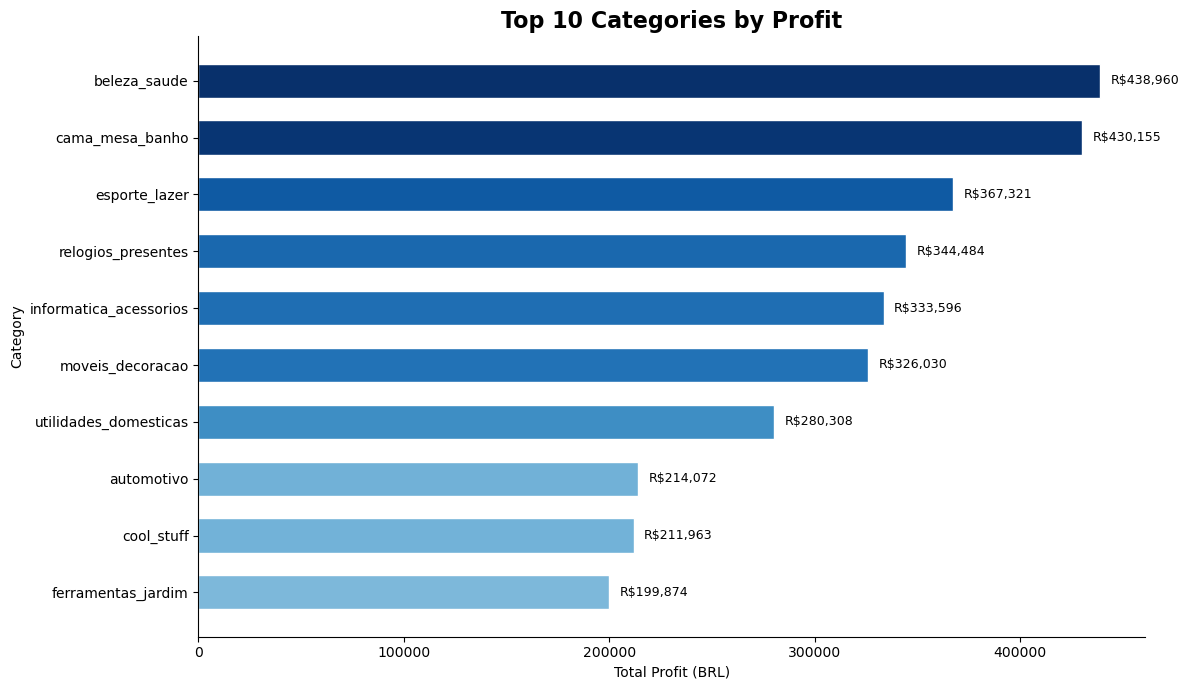

In [65]:
# --- Prepare Data ---
top10_profit = (
    category_performance_summary
    .sort_values('total_profit', ascending=True)
    .tail(10)
)

# --- Color Scale ---
values = top10_profit['total_profit'].values
colors = plt.cm.Blues([x / max(values) for x in values])

fig, ax = plt.subplots(figsize=(12, 7))

# --- Horizontal Bar with Color Scale ---
bars = ax.barh(top10_profit['product_category_name'],
               top10_profit['total_profit'],
               color=colors,
               edgecolor='white',
               height=0.6)

# --- Value Labels ---
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5000,
            bar.get_y() + bar.get_height() / 2,
            f'R${width:,.0f}',
            va='center', fontsize=9)

# --- Styling ---
ax.set_title('Top 10 Categories by Profit',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Total Profit (BRL)')
ax.set_ylabel('Category')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 8️⃣ Category Profit Margin %

Bar chart

✔ Margin leakage detection

------


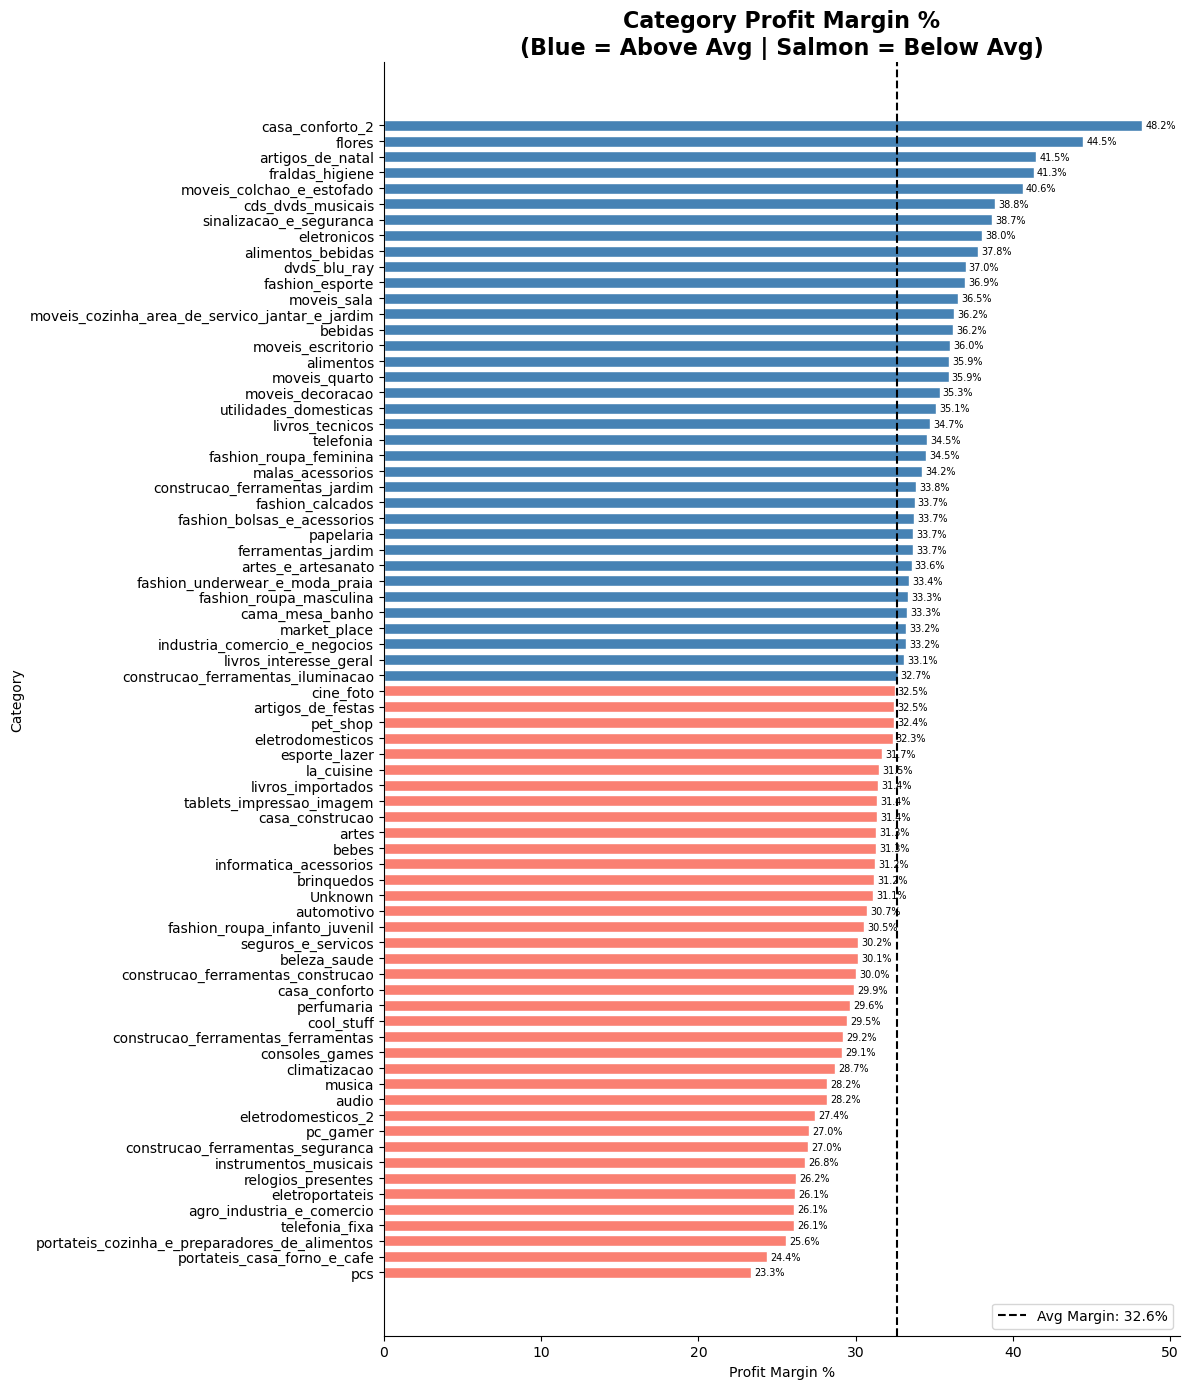

In [68]:
# --- Prepare Data ---
margin_data = (
    category_performance_summary
    .sort_values('profit_margin_%', ascending=True)
)

# --- Average Margin ---
avg_margin = margin_data['profit_margin_%'].mean()

# --- Conditional Colors ---
colors = ['steelblue' if x >= avg_margin else 'salmon'
          for x in margin_data['profit_margin_%']]

fig, ax = plt.subplots(figsize=(12, 14))

# --- Horizontal Bar ---
bars = ax.barh(margin_data['product_category_name'],
               margin_data['profit_margin_%'],
               color=colors,
               edgecolor='white',
               height=0.7)

# --- Average Line ---
ax.axvline(x=avg_margin,
           color='black',
           linewidth=1.5,
           linestyle='--',
           label=f'Avg Margin: {avg_margin:.1f}%')

# --- Value Labels ---
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{width:.1f}%',
            va='center', fontsize=7)

# --- Styling ---
ax.set_title('Category Profit Margin %\n(Blue = Above Avg | Salmon = Below Avg)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Profit Margin %')
ax.set_ylabel('Category')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 9️⃣ Category Scatter Plot (VERY IMPORTANT)

X = Revenue
Y = Profit Margin

This is strategic visual:

* High revenue + Low margin → leakage
* Low revenue + High margin → scale opportunity

This chart alone shows business thinking.

-----------

/tmp/ipykernel_218361/2343089709.py:65: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_218361/2343089709.py:65: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_218361/2343089709.py:65: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/ashutosh/miniconda3/envs/dev/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ashutosh/miniconda3/envs/dev/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ashutosh/miniconda3/envs/dev/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRC

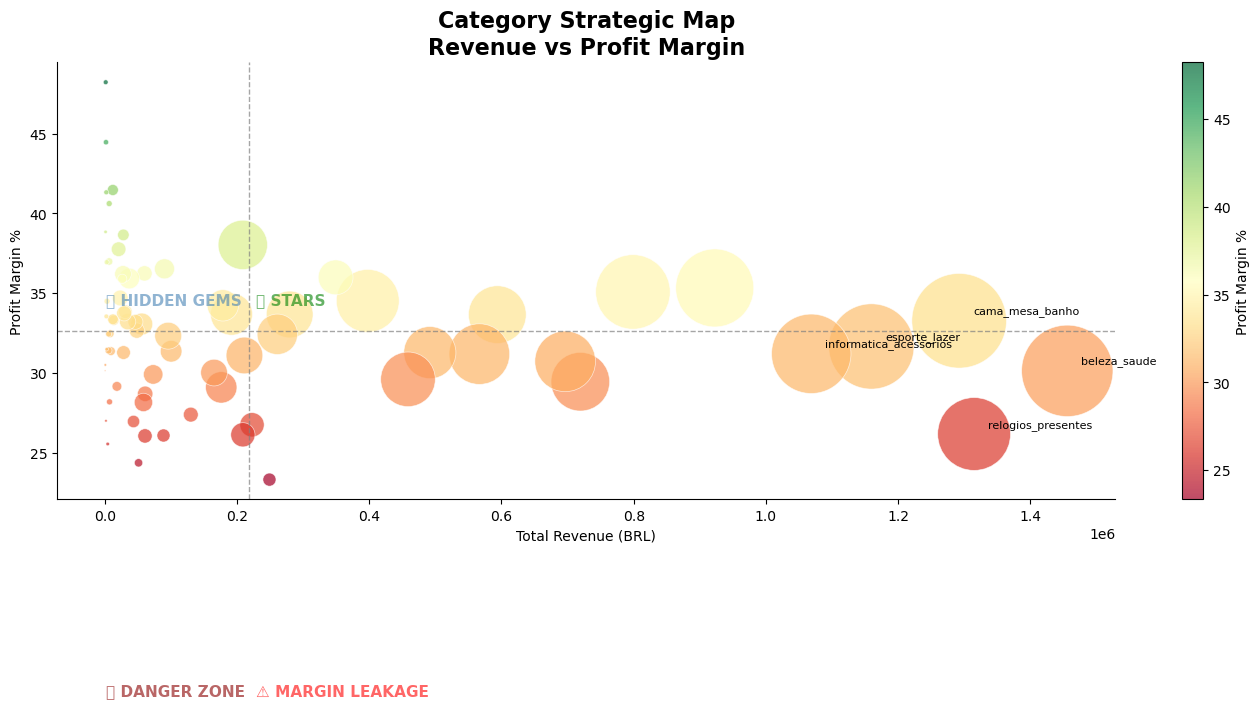

In [69]:
fig, ax = plt.subplots(figsize=(14, 8))

# --- Scatter Plot ---
scatter = ax.scatter(
    category_performance_summary['total_revenue'],
    category_performance_summary['profit_margin_%'],
    s=category_performance_summary['total_orders'] * 0.5,
    c=category_performance_summary['profit_margin_%'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

# --- Average Lines (Quadrant Dividers) ---
avg_rev    = category_performance_summary['total_revenue'].mean()
avg_margin = category_performance_summary['profit_margin_%'].mean()

ax.axvline(x=avg_rev, color='gray',
           linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(y=avg_margin, color='gray',
           linewidth=1, linestyle='--', alpha=0.7)

# --- Quadrant Labels ---
ax.text(avg_rev * 1.05, avg_margin * 1.05,
        '⭐ STARS', fontsize=11,
        fontweight='bold', color='green', alpha=0.6)

ax.text(avg_rev * 0.01, avg_margin * 1.05,
        '💎 HIDDEN GEMS', fontsize=11,
        fontweight='bold', color='steelblue', alpha=0.6)

ax.text(avg_rev * 1.05, avg_margin * 0.3,
        '⚠️ MARGIN LEAKAGE', fontsize=11,
        fontweight='bold', color='red', alpha=0.6)

ax.text(avg_rev * 0.01, avg_margin * 0.3,
        '🔴 DANGER ZONE', fontsize=11,
        fontweight='bold', color='darkred', alpha=0.6)

# --- Annotate Top 5 Categories ---
top5 = category_performance_summary.nlargest(5, 'total_revenue')

for _, row in top5.iterrows():
    ax.annotate(
        row['product_category_name'],
        xy=(row['total_revenue'], row['profit_margin_%']),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=8,
        color='black'
    )

# --- Colorbar ---
plt.colorbar(scatter, ax=ax, label='Profit Margin %')

# --- Styling ---
ax.set_title('Category Strategic Map\nRevenue vs Profit Margin',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Profit Margin %')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



### 🔟 Loss-Making Orders by Category

Bar chart

✔ Pricing or cost issue

-------

In [70]:
# --- Step 1: Filter Loss Orders ---
loss_orders = df[df['profit'] < 0]

# --- Step 2: Group & Count ---
loss_by_cat = (
    loss_orders
    .groupby('product_category_name')['profit']
    .count()
    .sort_values(ascending=True)
    .tail(10)
    .reset_index()
)
loss_by_cat.columns = ['category', 'loss_order_count']

print(loss_by_cat)

Empty DataFrame
Columns: [category, loss_order_count]
Index: []


In [71]:
print(df['profit'].describe())
print("\nMin profit:", df['profit'].min())
print("Max profit:", df['profit'].max())
print("Zero profit orders:", (df['profit'] == 0).sum())
print("Negative profit orders:", (df['profit'] < 0).sum())

count    115011.000000
mean         44.012377
std          45.447916
min           1.680000
25%          22.770000
50%          31.940000
75%          49.080000
max        1541.310000
Name: profit, dtype: float64

Min profit: 1.6799999999999995
Max profit: 1541.3100000000004
Zero profit orders: 0
Negative profit orders: 0


(28044, 44)
count    28044.000000
mean         0.729957
std          0.499186
min          0.400033
25%          0.477612
50%          0.594966
75%          0.803848
max         26.235294
Name: freight_ratio, dtype: float64


### 1️⃣1️⃣ Freight Ratio Impact

Scatter:
X = Revenue.                     
Y = Freight / Revenue.                      

✔ Logistics pressure detection

---

In [73]:
# --- Create Freight Ratio ---
df['freight_ratio'] = df['freight_value'] / df['price']

# --- Filter High Freight Orders ---
high_freight = df[df['freight_ratio'] > 0.4]

print("Total high freight orders:", high_freight.shape[0])
print("\nFreight Ratio Stats:")
print(high_freight['freight_ratio'].describe())

Total high freight orders: 28044

Freight Ratio Stats:
count    28044.000000
mean         0.729957
std          0.499186
min          0.400033
25%          0.477612
50%          0.594966
75%          0.803848
max         26.235294
Name: freight_ratio, dtype: float64


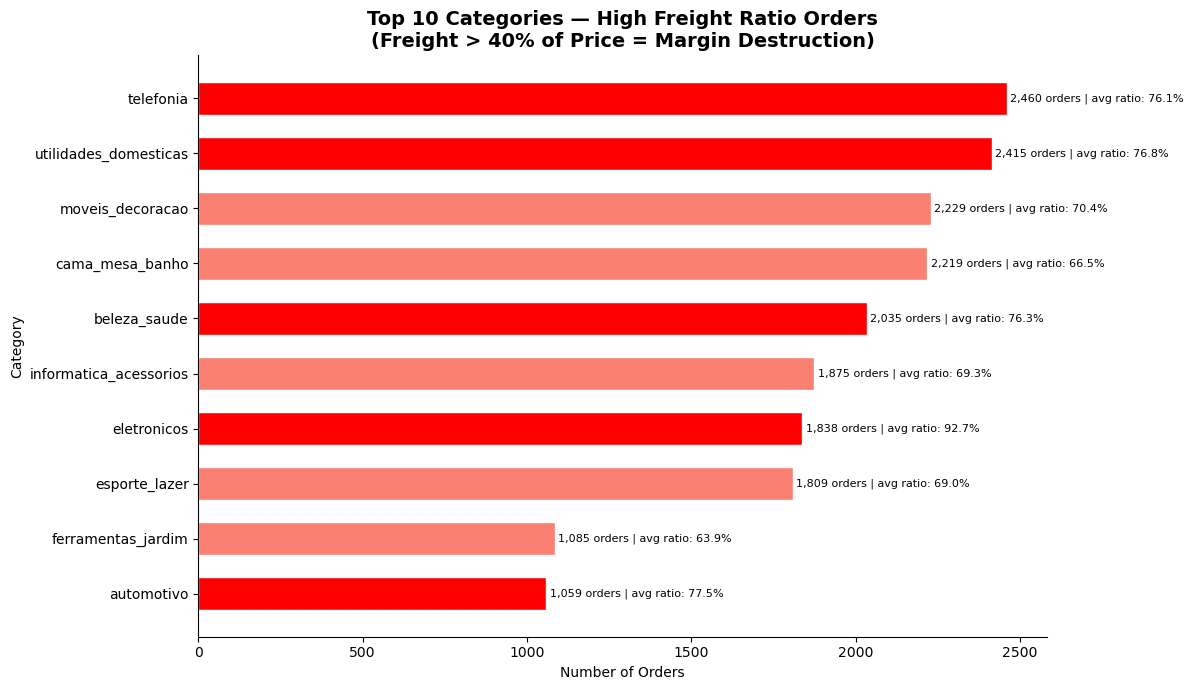

In [76]:
# --- Group by Category ---
high_freight_cat = (
    high_freight
    .groupby('product_category_name')
    .agg(
        loss_order_count=('freight_ratio', 'count'),
        avg_freight_ratio=('freight_ratio', 'mean')
    )
    .sort_values('loss_order_count', ascending=True)
    .tail(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

# --- Conditional Colors ---
avg_ratio = high_freight_cat['avg_freight_ratio'].mean()
colors = ['red' if x >= avg_ratio else 'salmon'
          for x in high_freight_cat['avg_freight_ratio']]

# --- Horizontal Bar ---
bars = ax.barh(high_freight_cat['product_category_name'],
               high_freight_cat['loss_order_count'],
               color=colors,
               edgecolor='white',
               height=0.6)

# --- Value Labels ---
for i, bar in enumerate(bars):
    width = bar.get_width()
    ratio = high_freight_cat['avg_freight_ratio'].iloc[i]
    ax.text(width + 10,
            bar.get_y() + bar.get_height() / 2,
            f'{width:,.0f} orders | avg ratio: {ratio:.1%}',
            va='center', fontsize=8)

# --- Styling ---
ax.set_title('Top 10 Categories — High Freight Ratio Orders\n(Freight > 40% of Price = Margin Destruction)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Category')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

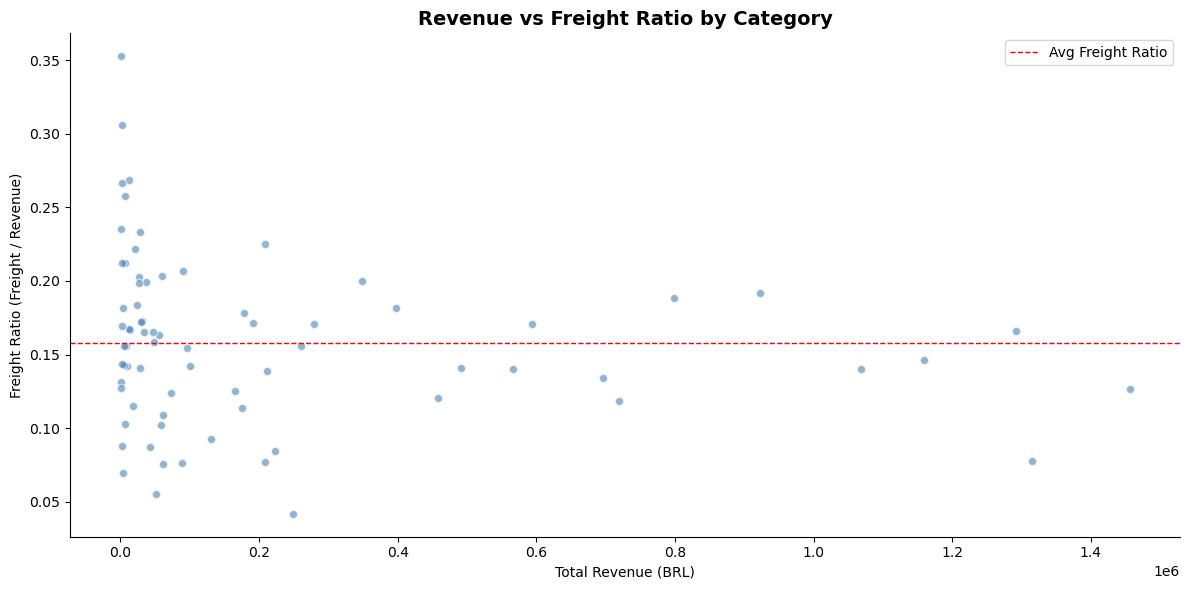

In [75]:
# --- Prepare Data ---
cat_data = category_performance_summary.copy()

fig, ax = plt.subplots(figsize=(12, 6))

# --- Scatter ---
ax.scatter(cat_data['total_revenue'],
           cat_data['freight_ratio_avg'],
           color='steelblue',
           alpha=0.6,
           edgecolors='white')

# --- Average Lines ---
ax.axhline(y=cat_data['freight_ratio_avg'].mean(),
           color='red', linestyle='--', linewidth=1,
           label='Avg Freight Ratio')

# --- Labels ---
ax.set_title('Revenue vs Freight Ratio by Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Freight Ratio (Freight / Revenue)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ✅ C. REGIONAL PERFORMANCE



### 1️⃣2️⃣ Revenue by State

Bar chart

------------

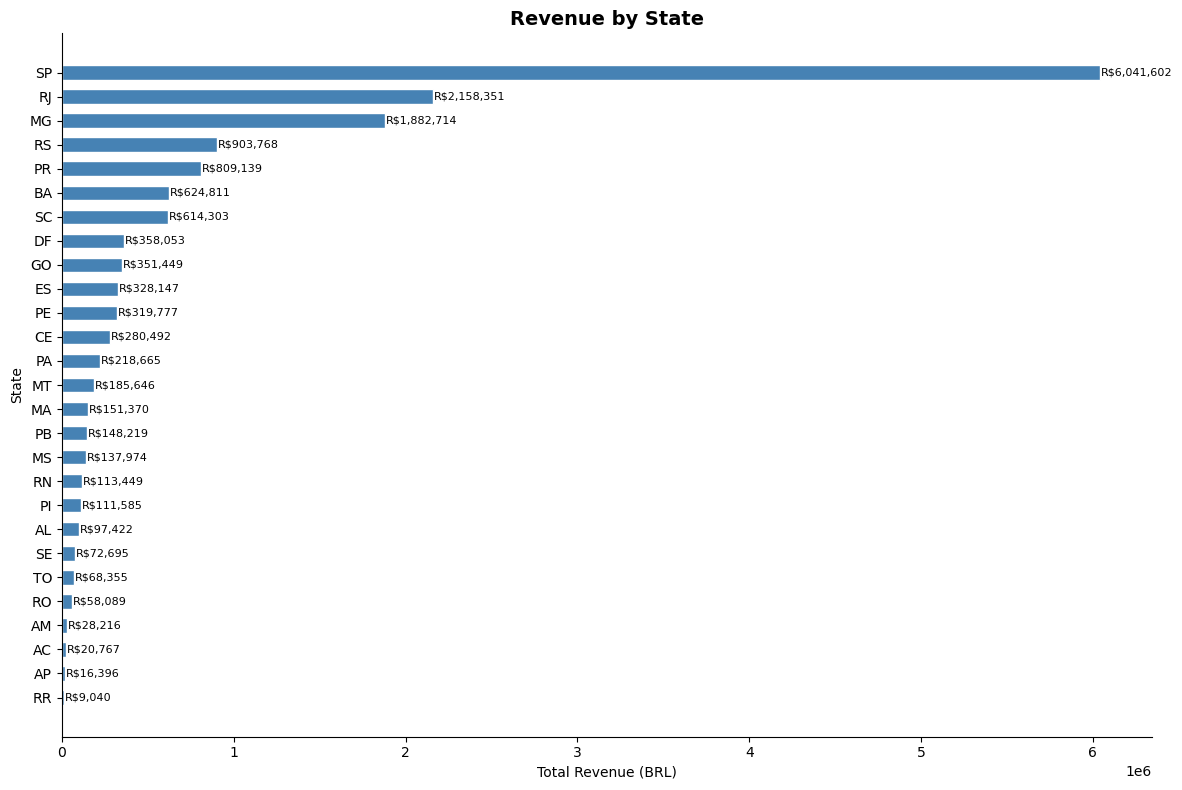

In [77]:
# --- Prepare Data ---
state_data = (
    state_performance_summary
    .sort_values('total_revenue', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 8))

# --- Horizontal Bar ---
bars = ax.barh(state_data['customer_state'],
               state_data['total_revenue'],
               color='steelblue',
               edgecolor='white',
               height=0.6)

# --- Value Labels ---
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5000,
            bar.get_y() + bar.get_height() / 2,
            f'R${width:,.0f}',
            va='center', fontsize=8)

# --- Styling ---
ax.set_title('Revenue by State',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('State')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 1️⃣3️⃣ Profit Margin by State

Bar chart

✔ Inefficient regions

--------

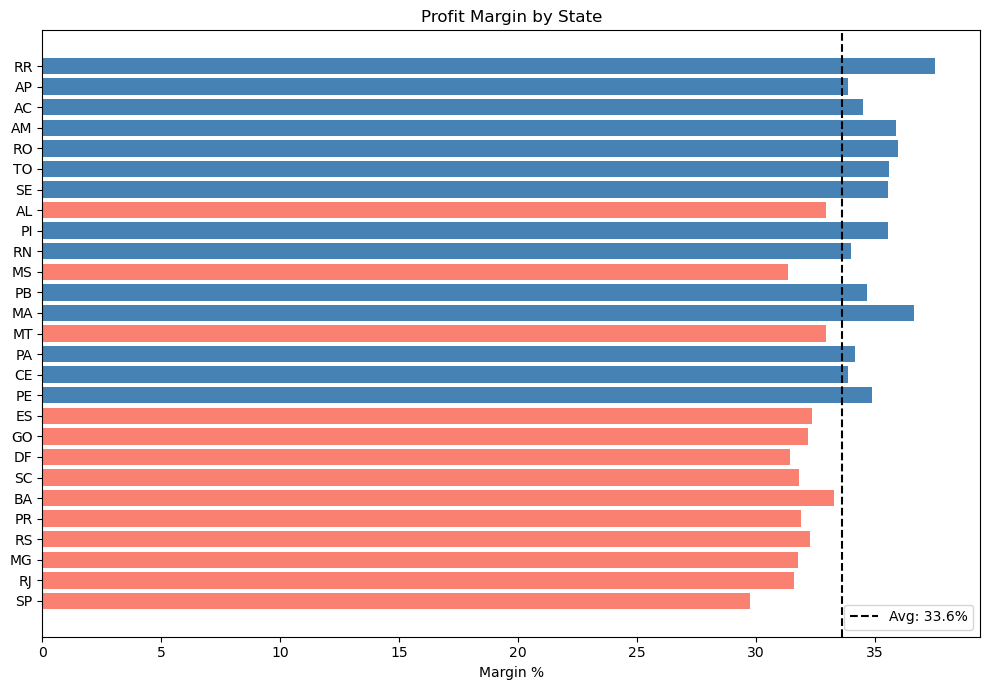

In [78]:
avg = state_performance_summary['profit_margin_%'].mean()

colors = ['steelblue' if x >= avg else 'salmon'
          for x in state_performance_summary['profit_margin_%']]

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(state_performance_summary['customer_state'],
        state_performance_summary['profit_margin_%'],
        color=colors)

ax.axvline(x=avg, color='black', linestyle='--',
           label=f'Avg: {avg:.1f}%')

ax.set_title('Profit Margin by State')
ax.set_xlabel('Margin %')
ax.legend()
plt.tight_layout()
plt.show()

### 1️⃣4️⃣ Orders by State

✔ Demand density.            

----------

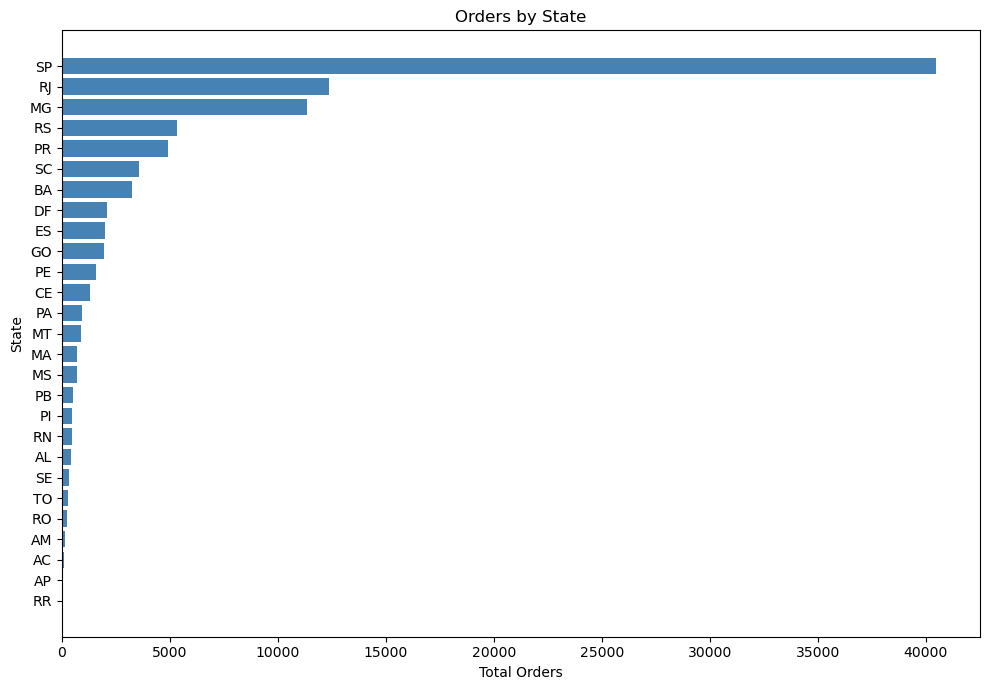

In [79]:
state_orders = (
    state_performance_summary
    .sort_values('total_orders', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(state_orders['customer_state'],
        state_orders['total_orders'],
        color='steelblue')

ax.set_title('Orders by State')
ax.set_xlabel('Total Orders')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

# ✅ D. CUSTOMER INTELLIGENCE (RFM + CLV)



### 1️⃣5️⃣ RFM Segment Distribution

Bar chart

✔ Customer quality mix

---

In [80]:
print(segment_summary.columns.tolist())
print(segment_summary.head())
print(segment_summary.shape)

['purchase_month', 'total_revenue', 'total_profit', 'total_orders', 'total_customers', 'profit_margin_%', 'AOV', 'MoM_growth_%', 'Revenue_3M_MA', 'MoM_growth_3M_avg_%', 'YoY_growth_%']
  purchase_month  total_revenue  total_profit  total_orders  total_customers  \
0        2016-10       48133.30      14789.48         265.0            265.0   
1        2016-11           0.00          0.00           0.0              0.0   
2        2016-12          19.62         10.90           1.0              1.0   
3        2017-01      136634.49      40604.42         748.0            748.0   
4        2017-02      283420.83      87946.99        1641.0           1641.0   

   profit_margin_%     AOV  MoM_growth_%  Revenue_3M_MA  MoM_growth_3M_avg_%  \
0            30.73  181.64           NaN            NaN                  NaN   
1              NaN     NaN       -100.00            NaN                  NaN   
2            55.56   19.62           NaN       16050.97                  NaN   
3            2

In [82]:
import datetime

# Fix datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

snapshot_date = df['order_purchase_timestamp'].max()

rfm = df.groupby('customer_unique_id').agg(
    recency  = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency= ('order_id', 'nunique'),
    monetary = ('revenue', 'sum')
).reset_index()

print(rfm.shape)
print(rfm.head())

(93335, 4)
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     27.19
2  0000f46a3911fa3c0805444483337064      536          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      320          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      287          1    196.89


In [85]:
# Use rank for frequency instead of qcut
rfm['R'] = pd.qcut(rfm['recency'],  4, labels=[4,3,2,1], duplicates='drop')
rfm['F'] = pd.cut(rfm['frequency'], bins=[0,1,2,3,100], labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4], duplicates='drop')

def segment(row):
    r = int(row['R'])
    f = int(row['F'])
    m = int(row['M'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r >= 3 and f <= 1:
        return 'New Customers'
    elif r == 2 and f >= 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

print(rfm['Segment'].value_counts())

Segment
Lost             45822
New Customers    45292
Loyal             1408
At Risk            672
Champions          141
Name: count, dtype: int64


In [86]:
print(rfm['Segment'].value_counts())

Segment
Lost             45822
New Customers    45292
Loyal             1408
At Risk            672
Champions          141
Name: count, dtype: int64


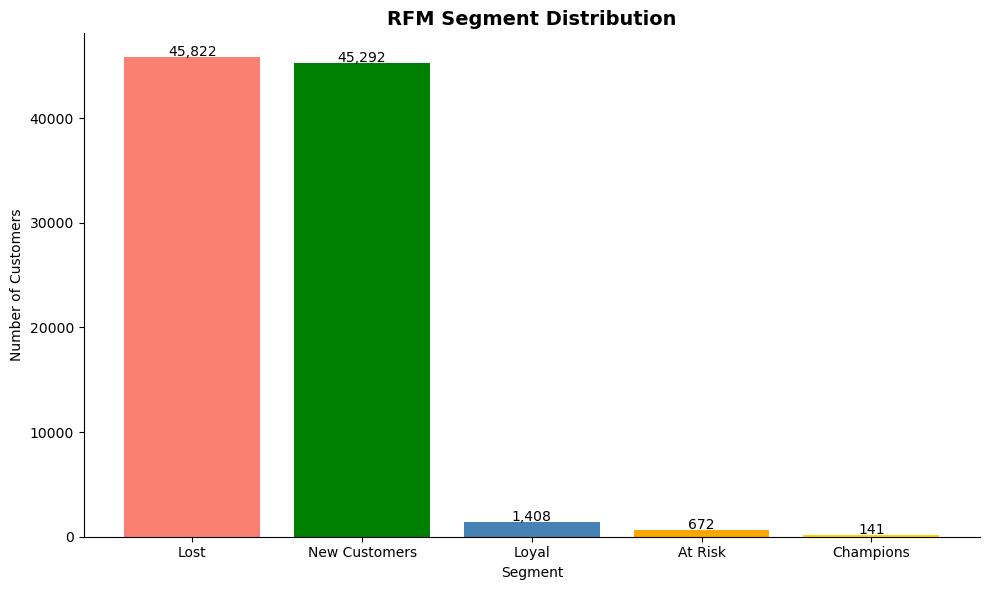

In [87]:
seg_counts = rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']

colors = {
    'Champions'    : 'gold',
    'Loyal'        : 'steelblue',
    'New Customers': 'green',
    'At Risk'      : 'orange',
    'Lost'         : 'salmon'
}

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(seg_counts['Segment'],
              seg_counts['Count'],
              color=[colors[s] for s in seg_counts['Segment']])

# --- Value Labels ---
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + 100,
            f'{height:,.0f}',
            ha='center', fontsize=10)

ax.set_title('RFM Segment Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 1️⃣6️⃣ Revenue by Segment

✔ Who drives money

---------

In [88]:
seg_revenue = rfm.groupby('Segment').agg(
    total_revenue=('monetary', 'sum'),
    total_customers=('customer_unique_id', 'count')
).reset_index().sort_values('total_revenue', ascending=False)

print(seg_revenue)

         Segment  total_revenue  total_customers
2           Lost     7777151.42            45822
4  New Customers     7608868.75            45292
3          Loyal      427885.68             1408
0        At Risk      218009.13              672
1      Champions       78576.58              141


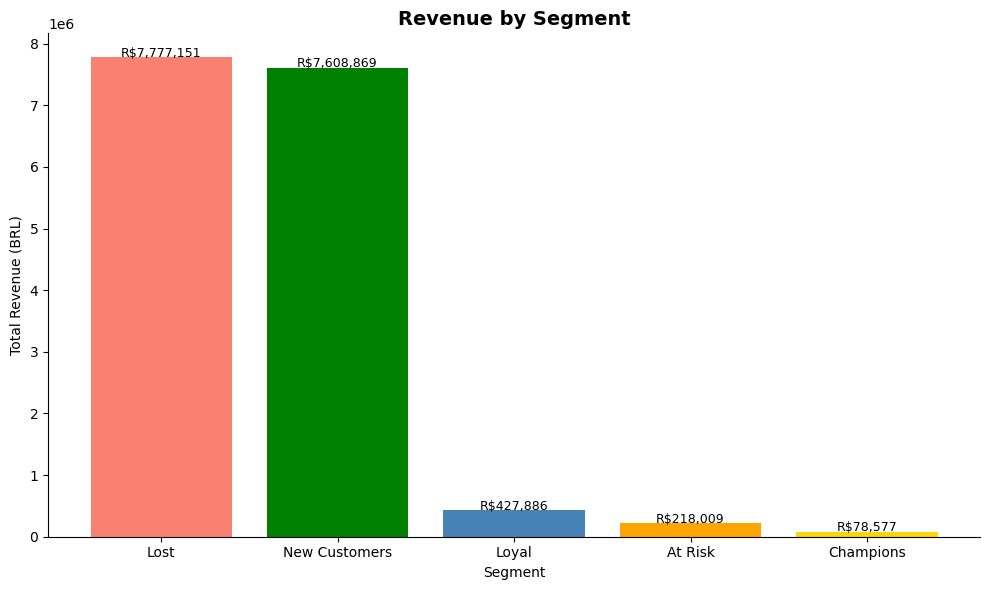

In [89]:
colors = {
    'Champions'    : 'gold',
    'Loyal'        : 'steelblue',
    'New Customers': 'green',
    'At Risk'      : 'orange',
    'Lost'         : 'salmon'
}

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(seg_revenue['Segment'],
              seg_revenue['total_revenue'],
              color=[colors[s] for s in seg_revenue['Segment']])

# --- Value Labels ---
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + 10000,
            f'R${height:,.0f}',
            ha='center', fontsize=9)

ax.set_title('Revenue by Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Total Revenue (BRL)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 1️⃣7️⃣ Profit by Segment

✔ High revenue but low profit?

-----------

In [90]:
seg_profit = rfm.groupby('Segment').agg(
    total_profit=('monetary', 'sum'),
).reset_index().sort_values('total_profit', ascending=False)

print(seg_profit)

         Segment  total_profit
2           Lost    7777151.42
4  New Customers    7608868.75
3          Loyal     427885.68
0        At Risk     218009.13
1      Champions      78576.58


In [91]:
# Merge actual profit from df
customer_profit = df.groupby('customer_unique_id')['profit'].sum().reset_index()
rfm = rfm.merge(customer_profit, on='customer_unique_id', how='left')

seg_profit = rfm.groupby('Segment').agg(
    total_revenue=('monetary', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()

seg_profit['profit_margin_%'] = (
    seg_profit['total_profit'] / seg_profit['total_revenue'] * 100
)

print(seg_profit)

         Segment  total_revenue  total_profit  profit_margin_%
0        At Risk      218009.13     69737.778        31.988467
1      Champions       78576.58     25766.244        32.791252
2           Lost     7777151.42   2417568.324        31.085525
3          Loyal      427885.68    140847.136        32.917002
4  New Customers     7608868.75   2407987.998        31.647122


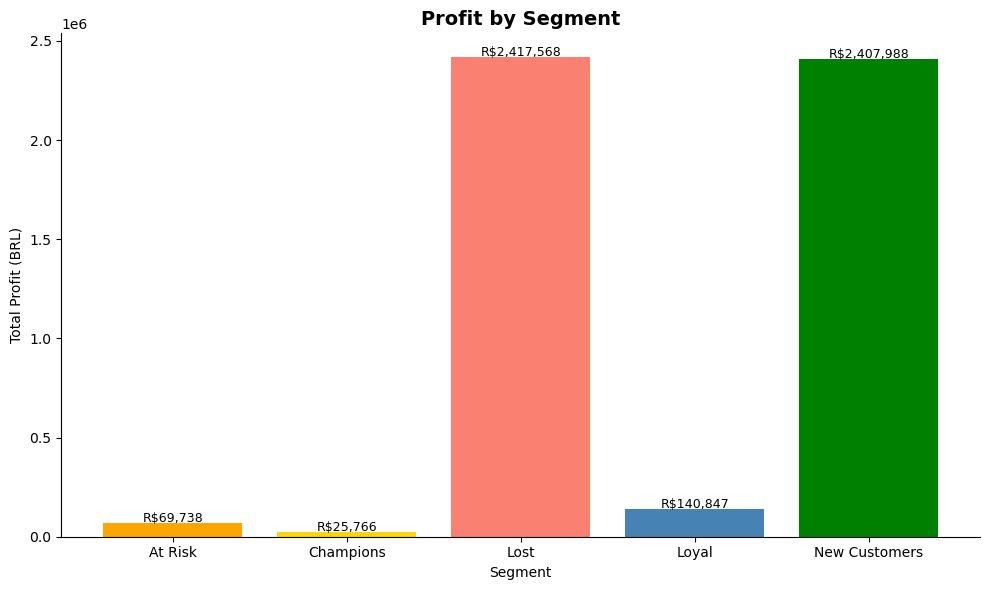

In [92]:
colors = {
    'Champions'    : 'gold',
    'Loyal'        : 'steelblue',
    'New Customers': 'green',
    'At Risk'      : 'orange',
    'Lost'         : 'salmon'
}

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(seg_profit['Segment'],
              seg_profit['total_profit'],
              color=[colors[s] for s in seg_profit['Segment']])

# --- Value Labels ---
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + 5000,
            f'R${height:,.0f}',
            ha='center', fontsize=9)

ax.set_title('Profit by Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Total Profit (BRL)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 1️⃣8️⃣ CLV Distribution (Histogram)

✔ Few high-value customers?

---------------

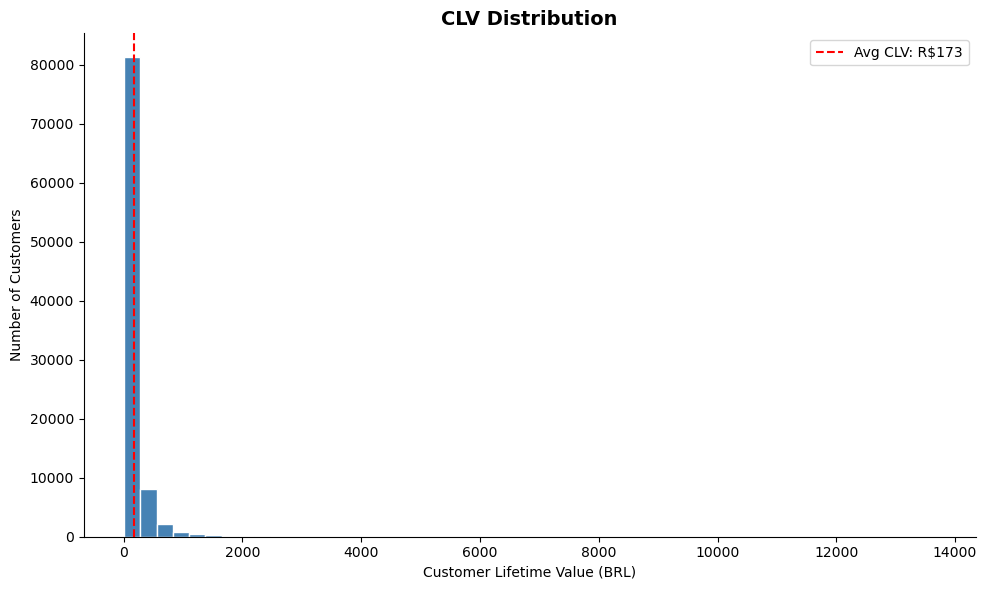

In [93]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(rfm['monetary'],
        bins=50,
        color='steelblue',
        edgecolor='white')

# --- Average Line ---
avg_clv = rfm['monetary'].mean()
ax.axvline(x=avg_clv, color='red',
           linestyle='--', linewidth=1.5,
           label=f'Avg CLV: R${avg_clv:.0f}')

ax.set_title('CLV Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Lifetime Value (BRL)')
ax.set_ylabel('Number of Customers')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 1️⃣9️⃣ Top 10 Customers by CLV

✔ Dependency risk

-------

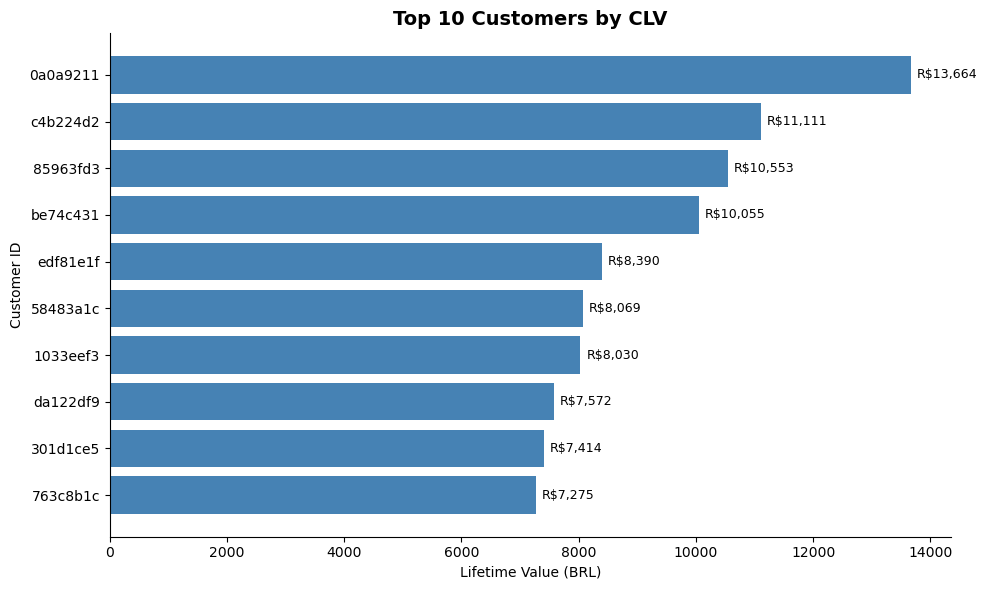

In [94]:
top10_clv = (
    rfm.sort_values('monetary', ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10_clv['customer_unique_id'].str[:8],
               top10_clv['monetary'],
               color='steelblue')

# --- Value Labels ---
for bar in bars:
    width = bar.get_width()
    ax.text(width + 100,
            bar.get_y() + bar.get_height() / 2,
            f'R${width:,.0f}',
            va='center', fontsize=9)

ax.set_title('Top 10 Customers by CLV', fontsize=14, fontweight='bold')
ax.set_xlabel('Lifetime Value (BRL)')
ax.set_ylabel('Customer ID')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ✅ E. RETENTION & CHURN

### 2️⃣0️⃣ Churn Distribution (Donut)

✔ 58.9% churn

------

In [95]:
# Churn = customer who bought only once
churn = rfm.copy()
churn['churned'] = (churn['frequency'] == 1).astype(int)

print(churn['churned'].value_counts())
print(f"\nChurn Rate: {churn['churned'].mean():.1%}")

churned
1    90535
0     2800
Name: count, dtype: int64

Churn Rate: 97.0%


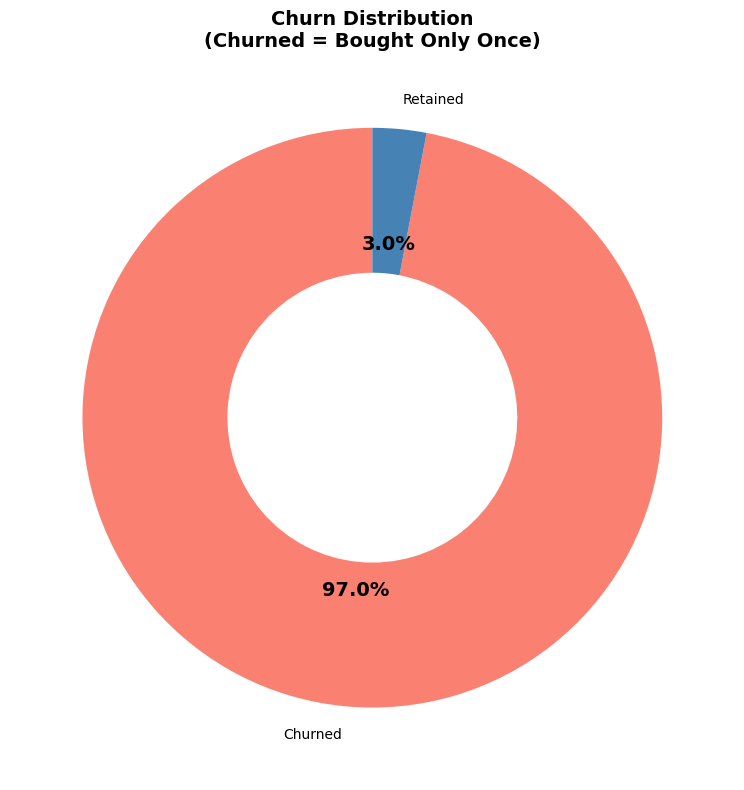

In [96]:
churn_counts = churn['churned'].value_counts()
labels = ['Churned', 'Retained']
colors = ['salmon', 'steelblue']

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    churn_counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5)
)

# --- Text Size ---
for text in autotexts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

ax.set_title('Churn Distribution\n(Churned = Bought Only Once)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2️⃣1️⃣ Recency Distribution (Histogram)

✔ How long customers stay inactive

--------

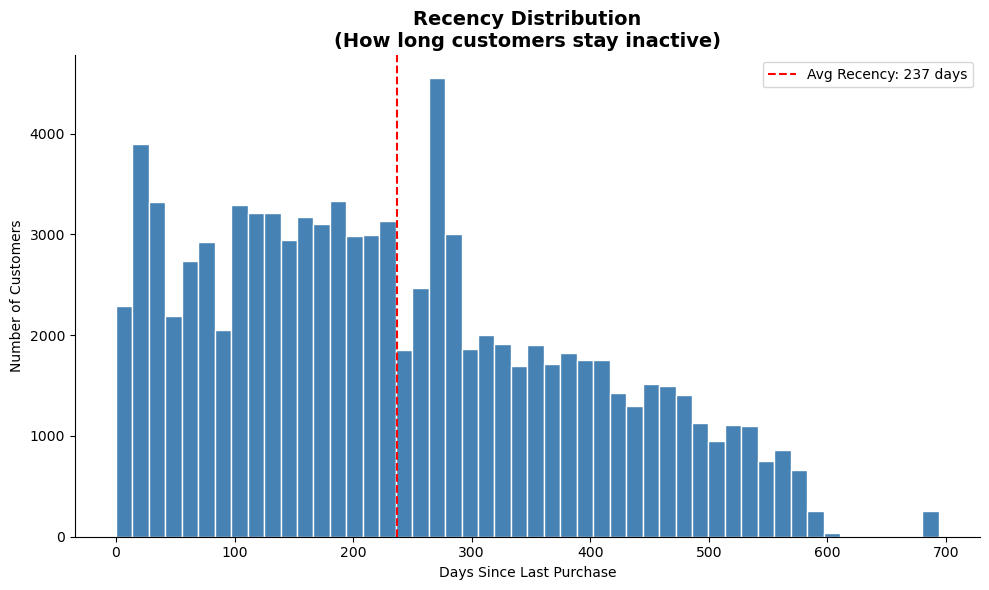

In [97]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(rfm['recency'],
        bins=50,
        color='steelblue',
        edgecolor='white')

# --- Average Line ---
avg_recency = rfm['recency'].mean()
ax.axvline(x=avg_recency, color='red',
           linestyle='--', linewidth=1.5,
           label=f'Avg Recency: {avg_recency:.0f} days')

ax.set_title('Recency Distribution\n(How long customers stay inactive)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Days Since Last Purchase')
ax.set_ylabel('Number of Customers')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 2️⃣2️⃣ Cohort Retention Heatmap

✔ Month 1 drop?
✔ Long-term loyalty?

This makes project advanced level.

-------

In [98]:
# --- Count unique customers per cohort & index ---
cohort_data = (
    df.groupby(['Cohort_Month', 'Cohort_Index'])
    ['customer_unique_id'].nunique()
    .reset_index()
)

# --- Pivot Table ---
cohort_pivot = cohort_data.pivot_table(
    index='Cohort_Month',
    columns='Cohort_Index',
    values='customer_unique_id'
)

# --- Retention % ---
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

print(retention.round(1).head())

Cohort_Index     0      1    2    3    4    5    6    7    8    9    10   11  \
Cohort_Month                                                                   
2016-10-01    100.0    NaN  NaN  NaN  NaN  NaN  0.4  NaN  NaN  0.4  NaN  0.4   
2016-12-01    100.0  100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2017-01-01    100.0    0.3  0.3  0.1  0.4  0.1  0.4  0.1  0.1  NaN  0.4  0.1   
2017-02-01    100.0    0.2  0.3  0.1  0.4  0.1  0.2  0.2  0.1  0.2  0.1  0.3   
2017-03-01    100.0    0.4  0.4  0.4  0.4  0.2  0.2  0.3  0.3  0.1  0.4  0.1   

Cohort_Index   12   13   14   15   16   17   19   20  
Cohort_Month                                          
2016-10-01    NaN  0.4  NaN  0.4  NaN  0.4  0.8  0.8  
2016-12-01    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2017-01-01    0.7  0.4  0.1  0.1  0.3  0.4  0.1  NaN  
2017-02-01    0.1  0.2  0.1  0.1  0.1  0.2  NaN  NaN  
2017-03-01    0.2  0.1  0.2  0.2  0.1  0.1  NaN  NaN  


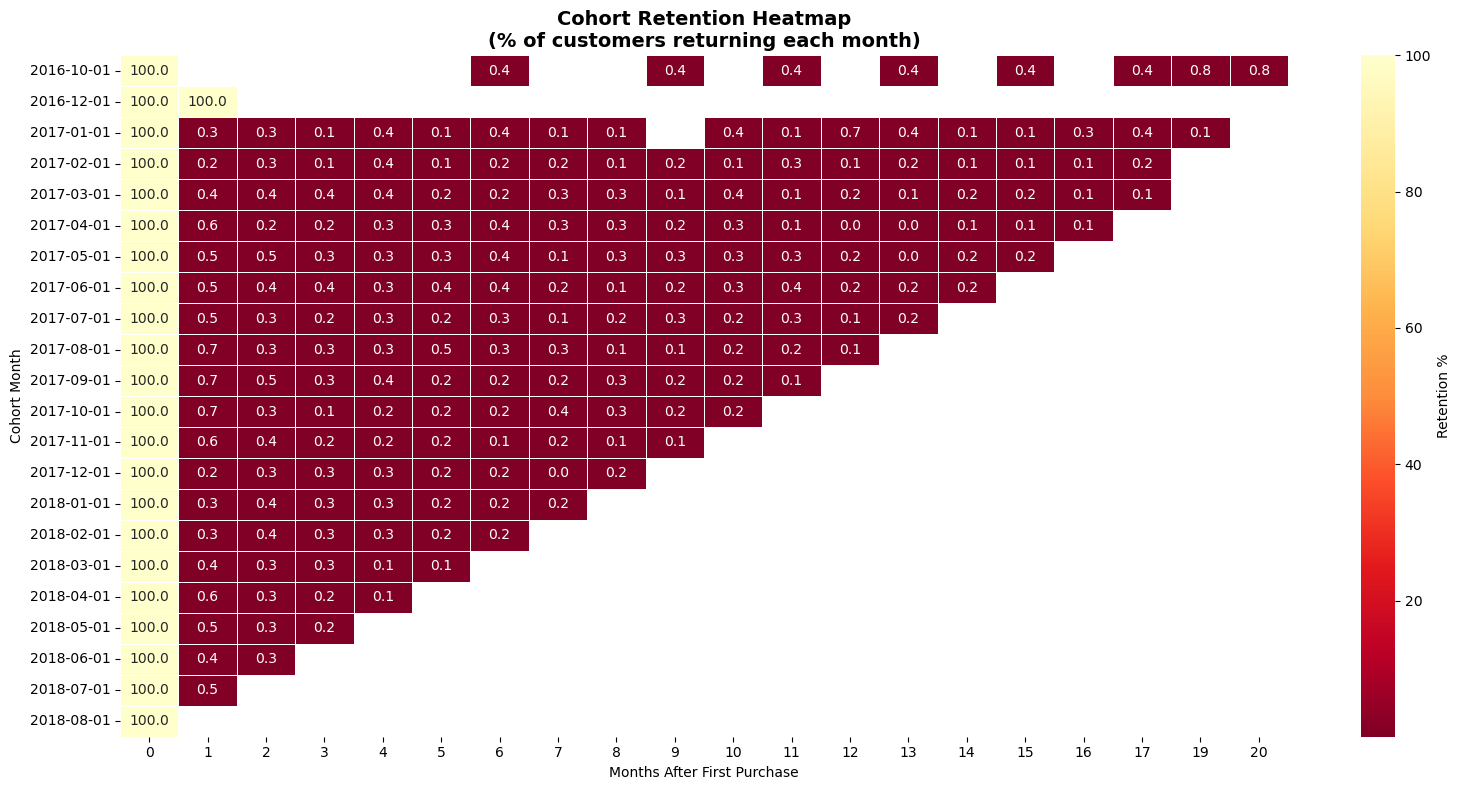

In [100]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(retention,
            annot=True,
            fmt='.1f',
            cmap='YlOrRd_r',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Retention %'})

ax.set_title('Cohort Retention Heatmap\n(% of customers returning each month)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Months After First Purchase')
ax.set_ylabel('Cohort Month')

plt.tight_layout()
plt.show()

# ✅ F. PARETO ANALYSIS


### 2️⃣3️⃣ Cumulative Revenue Curve

* Sorted customers
* 80% line

✔ Revenue concentration
✔ Dependency analysis

---

In [104]:
import numpy as np

In [105]:
pareto = rfm.sort_values('monetary', ascending=False).copy()

pareto['cumulative_revenue'] = pareto['monetary'].cumsum()
pareto['cumulative_revenue_%'] = (
    pareto['cumulative_revenue'] / pareto['monetary'].sum() * 100
)

# --- Fix ---
pareto['cumulative_customers_%'] = (
    np.arange(1, len(pareto) + 1) / len(pareto) * 100
)

print(pareto[['monetary',
              'cumulative_revenue_%',
              'cumulative_customers_%']].head(10))

       monetary  cumulative_revenue_%  cumulative_customers_%
3724   13664.08              0.084815                0.001071
71801  11111.40              0.153785                0.002143
48724  10553.28              0.219290                0.003214
69541  10055.22              0.281705                0.004286
86868   8389.52              0.333779                0.005357
32271   8068.88              0.383864                0.006428
5957    8030.46              0.433710                0.007500
79616   7571.63              0.480708                0.008571
17613   7413.70              0.526726                0.009643
43161   7274.88              0.571882                0.010714


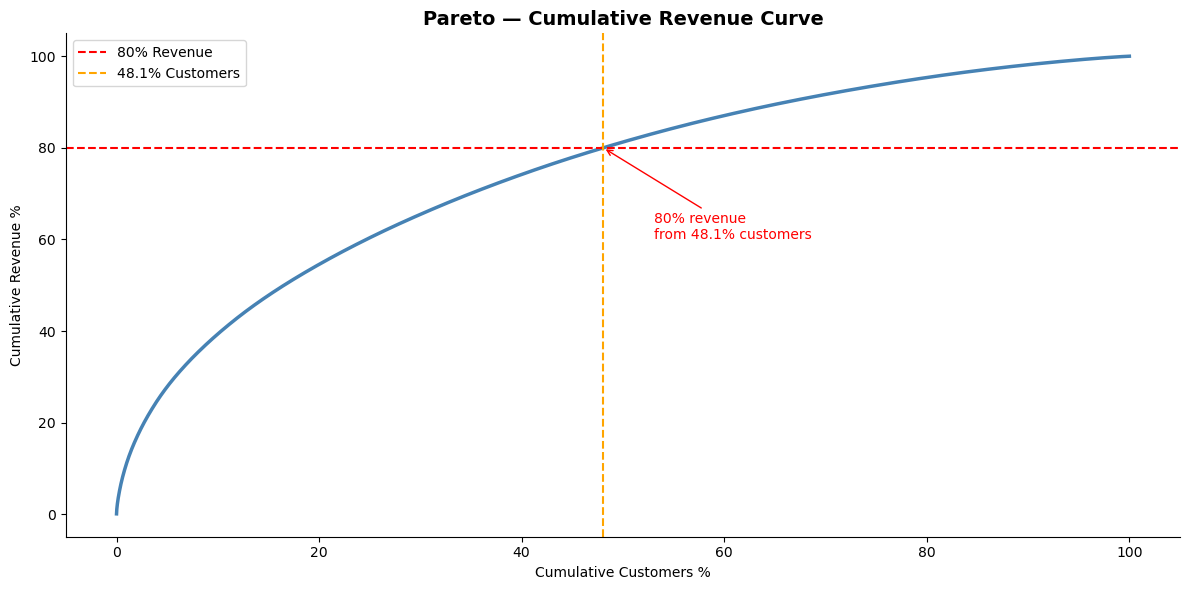

In [106]:
fig, ax = plt.subplots(figsize=(12, 6))

# --- Cumulative Revenue Curve ---
ax.plot(pareto['cumulative_customers_%'],
        pareto['cumulative_revenue_%'],
        color='steelblue', linewidth=2.5)

# --- 80% Line ---
ax.axhline(y=80, color='red', linestyle='--',
           linewidth=1.5, label='80% Revenue')

# --- Find where curve hits 80% ---
idx = (pareto['cumulative_revenue_%'] >= 80).idxmax()
x_80 = pareto.loc[idx, 'cumulative_customers_%']

ax.axvline(x=x_80, color='orange', linestyle='--',
           linewidth=1.5, label=f'{x_80:.1f}% Customers')

# --- Annotation ---
ax.annotate(f'80% revenue\nfrom {x_80:.1f}% customers',
            xy=(x_80, 80),
            xytext=(x_80 + 5, 60),
            fontsize=10,
            color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('Pareto — Cumulative Revenue Curve',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Cumulative Customers %')
ax.set_ylabel('Cumulative Revenue %')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()